# D09 · From coefficients to a defensible contrast

<!-- paper-first -->
### Research question

**Reading:** [PD01](../../curriculum/papers/design.md#pd01). Review the assigned figure or result before starting the lesson.

**Question:** Could similar fitted maps produce different answers because analysts tested different contrasts?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

A general linear model represents an outcome as a weighted sum of named design columns plus residuals. Least squares chooses weights that minimize squared residuals; inference asks how uncertain a specified combination of those weights is under a noise model. The two tasks must not be conflated. A solver can fit a line without validating independence, the measurement model, or a causal interpretation.

A contrast c extracts a quantity c-transpose-beta. With columns intercept, A, and B, A-minus-B uses weights zero, one, minus one. Its standard error uses the coefficient covariance, including covariance between A and B. Adding separate coefficient standard errors is incorrect. A t statistic divides the effect by its standard error. A two-sided p value describes the probability of a statistic at least as extreme under the null model; it is not the probability the null is true or the percentage chance the effect replicates.

An F test asks whether a collection of linear restrictions is simultaneously compatible with zero. For one restriction, F equals t squared and loses direction. A multi-row F test can identify evidence that some combination differs from zero without identifying which coefficient or sign drives it. A statistical z score may re-express a t-test tail probability on a normal scale; it is not the same as z-standardizing measured outcomes. Neither t nor z is an effect magnitude in percent BOLD signal.

The synthetic observations below are independent with normal errors and fixed predictors. We use the correct ordinary least-squares covariance for that generator. This is not an fMRI time-series inference pipeline: temporally correlated residuals require appropriate covariance treatment, explored next. Degrees of freedom are observations minus design rank in this simple model, not automatically scans minus the number of task conditions. Nuisance columns and intercepts count too. We reverse contrast direction and reorder columns to expose errors that would survive an ordinary code-completion check.

Predict the sign of A-minus-B. Inspect named columns and residual degrees of freedom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(209)
n = 120
X = np.column_stack([np.ones(n), np.linspace(-1,1,n), np.sin(np.arange(n))])
names = ['intercept','A','B']; true_beta = np.array([10.,2.,.5])
y = X @ true_beta + rng.normal(size=n)
beta = np.linalg.lstsq(X,y,rcond=None)[0]
residual = y-X@beta; df=n-np.linalg.matrix_rank(X)
cov = (residual@residual/df)*np.linalg.inv(X.T@X)
c = np.array([0.,1.,-1.]); effect=c@beta; se=np.sqrt(c@cov@c)
t_value=effect/se; p=2*stats.t.sf(abs(t_value),df)
ci=effect+np.array([-1,1])*stats.t.ppf(.975,df)*se
assert df==117 and effect>0
print('Named contrast:',dict(zip(names,c)))
print('Effect, SE, t, p, 95% CI:',effect,se,t_value,p,ci)

Named contrast: {'intercept': np.float64(0.0), 'A': np.float64(1.0), 'B': np.float64(-1.0)}
Effect, SE, t, p, 95% CI: 1.6528922499130048 0.2068152147506588 7.992121140148077 1.0443933675024853e-12 [1.24330555 2.06247895]


Equivalent parameter order should preserve the answer; one-row F should equal t squared.

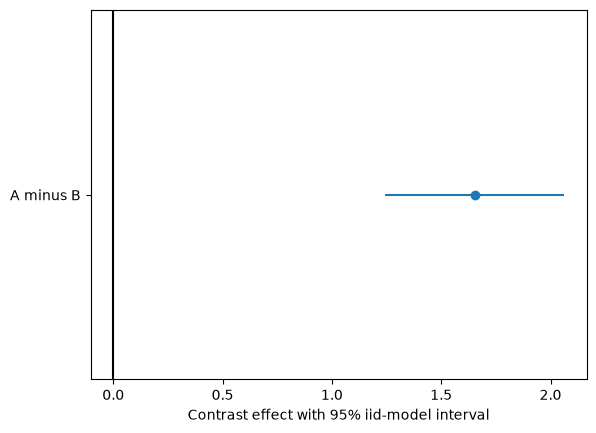

One-restriction F / signed equivalent z: 63.8740003188018 7.124526182182471


In [2]:
order = [2,0,1]
reordered = np.linalg.lstsq(X[:,order],y,rcond=None)[0]
assert np.isclose(c[order]@reordered,effect)
assert np.isclose((-c)@beta,-effect)
F = (c@beta)**2/(c@cov@c)
assert np.isclose(F,t_value**2)
assert np.isclose(stats.f.sf(F,1,df),p)
z = np.sign(t_value)*stats.norm.isf(stats.t.sf(abs(t_value),df))
assert np.isclose(2*stats.norm.sf(abs(z)),p)
plt.errorbar([effect],[0],xerr=[[effect-ci[0]],[ci[1]-effect]],fmt='o')
plt.axvline(0,color='black'); plt.yticks([0],['A minus B'])
plt.xlabel('Contrast effect with 95% iid-model interval'); plt.show()
print('One-restriction F / signed equivalent z:',F,z)

## Supervise the AI, then transfer the idea

**AI prompt:** “Translate the verbal hypothesis into weights against named columns. Explain effect, standard error, t, F, z, and p separately. Reorder the columns and predict how the contrast must change. Give a 15-line audit with the degrees of freedom and iid-normal limitation.”

**Deliberate mistake:** reuse the old vector after moving B to the first column. Explain why the resulting number is a different question even if it is significant. Transfer to actual software by inspecting design column names, contrast scaling, derivatives, run constants, high-pass basis, and the reported noise model. Save both contrast-effect and uncertainty/statistic images; a thresholded map alone hides effect magnitude and uncertainty. Deliver a units-aware result sentence and an equivalent contrast after column reordering.

## Answer key — read after your own explanation

The true generating A-minus-B is 1.5, while the noisy fitted value varies around it. Reordering columns and weights together preserves the effect. Reversing the contrast reverses t, preserving the two-sided p value. A one-row F equals t squared; multi-row F does not provide a sign. The interval and p value are valid only under the toy model's assumptions, not merely because their formulas executed.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Berkeley hypothesis_tests.rst](https://github.com/bic-berkeley/psych-214-fall-2016/blob/ec44652addc92091183456fa04fcd41dca0e172e/hypothesis_tests.rst); [DartBrains GLM](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/GLM.ipynb); [MIT 9.07 lectures 11–13](https://ocw.mit.edu/courses/9-07-statistics-for-brain-and-cognitive-science-fall-2016/pages/syllabus/). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Revisit [PD01](../../curriculum/papers/design.md#pd01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
